In [99]:
import numpy as np
import matplotlib.pyplot as plt
#from mfld import MeanFieldLangevinDynamics
import jax_kernels as ker
import functions as f
import time
from variational_inference import VariationalInference

import jax.numpy as jnp
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
import random
import jax
from jax import random

from jax.flatten_util import ravel_pytree
from jax import grad, random,vmap,tree_util

In [100]:

def generate_data(key, s, N, noise_std=0.1):
    key_z, key_noise = random.split(key)
    
    Z = random.uniform(key_z, (N, s),minval = 0,maxval=1.0)  # uniform distribution [-1,1]

    #explanation function
    def f(z):
        return jnp.sin(2 * jnp.pi * z[:,0])#, 0]) + 0.5 * Z[:, 1]**2 - jnp.exp(-Z[:, 2])

    Y_clean = f(Z)

    # noise
    noise = noise_std * random.normal(key_noise, shape=Y_clean.shape)
    Y= Y_clean + noise

    return Z, Y

N = 300
s=1 #input dimension 
key_data = random.PRNGKey(8)
Z,Y = generate_data(key_data,s, N, noise_std=0.1) # put more noise
#plt.plot(Z,Y,".")


In [118]:
kernel_name = "IMQ"
c = jnp.array(1.0)
b = 3.0
def k(x,y):
    return (c**2 + (x-y).dot(x-y))**(-b) #+ 6*jnp.dot(x,y) + jnp.exp(-((x-y).dot(x-y)/2**2))
    #return jnp.dot(x,y)
# scale = 1
# k = lambda x, y: jnp.exp(-((x-y).dot(x-y)/scale**2))

def q_0(x):
    d = jax.lax.stop_gradient(len(x))
    return jnp.exp(-jnp.dot(x,x)/(2*4)) #/ jnp.sqrt((2 * jnp.pi)**d)


def esp_forward(X, z):
    E = jnp.mean(jit(vmap(lambda x : model.apply(unravel_fn(x), z)))(X))
    return E
gamma = 100
lambd = 1e-0
def L(X):  
    n = len(X)
    Esp_forward = vmap(lambda z: esp_forward(X, z))(Z)  
    return gamma * jnp.mean((Esp_forward - Y) ** 2)

key = random.PRNGKey(0)
hidden_dim = 1
model = f.MLP(hidden_dims=[hidden_dim], output_dim=1, activation_function ="relu")

params = model.init(key, jnp.ones((s,)))  
flat_params, unravel_fn = ravel_pytree(params)
d = len(flat_params)  


k = jit(k)
q_0 = jit(q_0)
esp_forward = jit(esp_forward)
L = jit(L)  
 
learning_rate = 1e-5
VI = VariationalInference(q_0, L, k, d,[20,20],"elu", learning_rate) 
F_P = f.F_P(q_0, L)
k_pq = f.GradientKernel(VI.S_PQ,k)
KGD = f.KernelGradientDiscrepancy(k_pq)
gradX_KGD = jit(grad(KGD.evaluate))

In [119]:
#Upload results
import pickle

# Chargement depuis le fichier
with open("results_nn.pkl", "rb") as f:
    results_NN_loaded = pickle.load(f)

In [124]:
T = 100000
n = 100
step_size = 1e-1

key_init = random.PRNGKey(200)
X_list = [model.init(random.fold_in(key_init, i),jnp.ones((s,))) for i in range(n)]
flat_X_list = [ravel_pytree(p)[0] for p in X_list] 
X0 = random.uniform(key_init, (n, d),minval = -5,maxval=5.0)
X = X0.copy()

KGD_list = []
for it in range(T):
    X = X - step_size * gradX_KGD(X)
    KGD_value = KGD.evaluate(X)
    KGD_list.append(KGD_value)
X_fin = X

Text(0, 0.5, 'KGD')

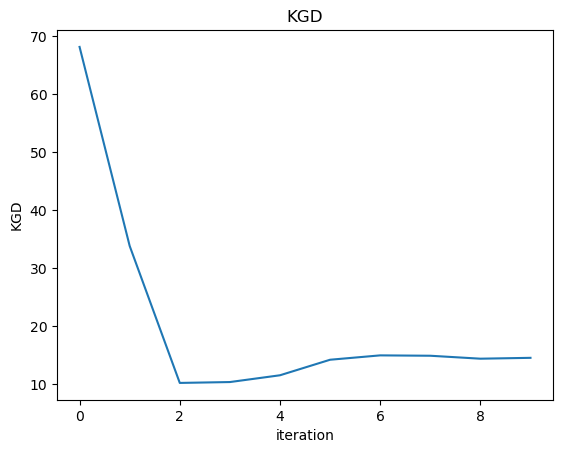

In [125]:
plt.plot(KGD_list[:10])
plt.title("KGD")
plt.xlabel("iteration")
plt.ylabel("KGD")

Text(0.5, 1.0, 'after training')

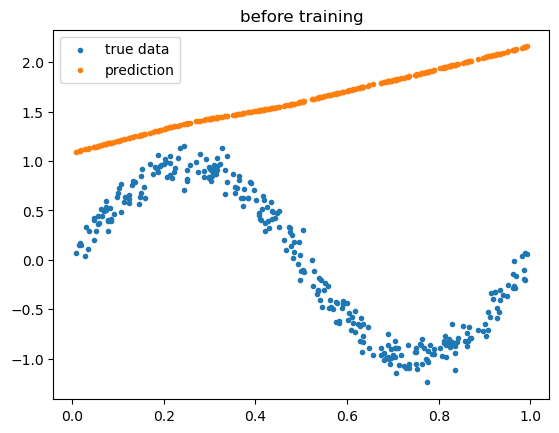

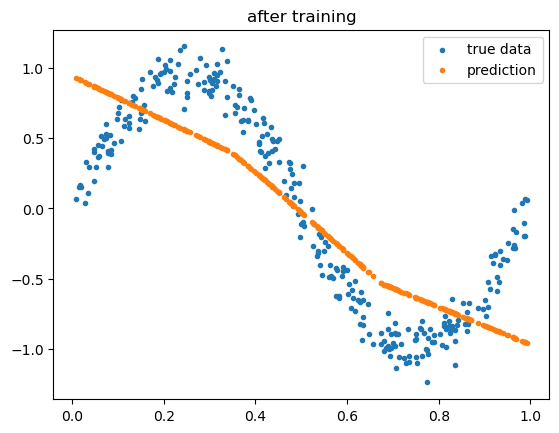

In [126]:
plt.figure()
plt.scatter(Z,Y,label = "true data",marker = ".")
Y_hat = vmap(lambda z : esp_forward(X0, z))(Z)
plt.scatter(Z,Y_hat,label = "prediction",marker = ".")
plt.legend()
plt.title("before training")

plt.figure()
plt.scatter(Z,Y,label = "true data",marker = ".")
Y_hat = vmap(lambda z : esp_forward(X_fin, z))(Z)
plt.scatter(Z,Y_hat,label = "prediction",marker = ".")
plt.legend()
plt.title("after training")


(-6.685258412361145, 6.063515686988831, -5.2308330059051515, 5.238161993026734)

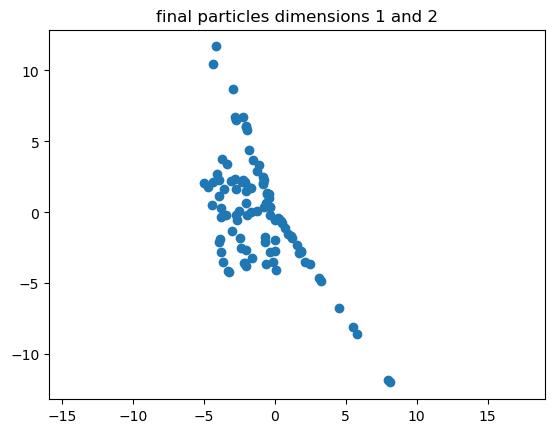

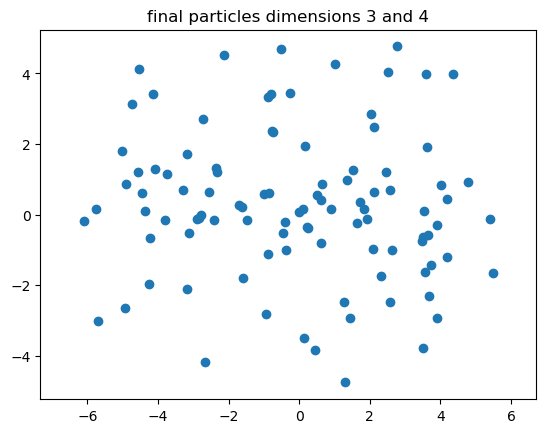

In [127]:
plt.figure()
plt.scatter(X[:,0],X[:,1])
plt.title("final particles dimensions 1 and 2")
plt.axis('equal')

plt.figure()
plt.scatter(X[:,2],X[:,3])
plt.title("final particles dimensions 3 and 4")
plt.axis('equal')

In [128]:
results_NN_loaded["VI"]["X_fin"] = X_fin

In [129]:
import pickle

# Sauvegarde dans un fichier binaire
with open("results_nn.pkl", "wb") as g:
    pickle.dump(results_NN_loaded, g)